In [39]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from properscoring import crps_ensemble
import os
import sys
import calendar

In [40]:
# Add the path to the src directory (two levels up)
sys.path.append(os.path.abspath('../../'))
from src.data_loader import DataLoader
from src.data_processor import CFSTransformer, CNBSForecaster, ForecastTransformer
from src.database_utils import CFSDatabase
from src.plotting import plot_cnbs_forecast, plot_cnbs_forecast_interactive
from src.utilities import get_first_forecast_month
from src.data_processor import SeasonalCycleProcessor

In [41]:
# Directory where the repository is cloned
local_path = '/Users/ljob/Desktop/'

# Path to data directory
input_dir = local_path + 'cnbs-predictor/data/'

# Path to input CFS forecast database
cfs_database = local_path+ 'Data/cfs_forecast_archive_2011-2026.db'
cfs_table = 'cfs_forecast_data'

# Path to save CNBS forecast output to a database
cnbs_database = local_path + 'Data/cnbs_forecast_verification.db'
cnbs_table = 'cnbs_forecast'

# Path to GLSEA SST data
glsea_data = input_dir + 'glsea/oisst_sst_1981-2024.csv'

# Path to saved scalers
model_dir = input_dir + "input/models/"
scaler_dir = input_dir + "input/scalers/"

# List of models to run
models_info = ['GP', 'RF', 'NN', 'XGB']

In [42]:
# Load CFS forecast data from the database and format it before predicting CNBS
data = CFSDatabase(cfs_database, cfs_table).load()

In [43]:
print(data)

            cfs_run  year  month      lake surface_type        component  \
0        2011040100  2011      4      erie         lake  air_temperature   
1        2011040100  2011      4      erie         lake      evaporation   
2        2011040100  2011      4      erie         lake    precipitation   
3        2011040100  2011      4      erie         land  air_temperature   
4        2011040100  2011      4      erie         land      evaporation   
...             ...   ...    ...       ...          ...              ...   
4394720  2026030118  2026     12  superior         lake      evaporation   
4394721  2026030118  2026     12  superior         lake    precipitation   
4394722  2026030118  2026     12  superior         land  air_temperature   
4394723  2026030118  2026     12  superior         land      evaporation   
4394724  2026030118  2026     12  superior         land    precipitation   

         value [mm]  
0        278.204989  
1         30.604513  
2        151.103405  

In [44]:
data['column_name'] = (
            data['lake'] + '_' +
            data['surface_type'] + '_' +
            data['component']
        )
data['forecast_date'] = pd.to_datetime(dict(year=data['year'], month=data['month'], day=1))
df_wide = data.pivot(index=['cfs_run', 'forecast_date'], columns=['column_name'], values='value [mm]')
df_wide.reset_index(inplace=True)
df_wide.columns.name = None  # Remove the name of the columns index
df_wide = df_wide.set_index('forecast_date')  # Set forecast_date as the index
print(df_wide)

                  cfs_run  erie_lake_air_temperature  erie_lake_evaporation  \
forecast_date                                                                 
2011-04-01     2011040100                 278.204989              30.604513   
2011-05-01     2011040100                 281.828651              61.628583   
2011-06-01     2011040100                 288.563218              76.472143   
2011-07-01     2011040100                 291.785560              87.971038   
2011-08-01     2011040100                 291.993982              77.764639   
...                   ...                        ...                    ...   
2026-08-01     2026030118                 290.368913              68.751325   
2026-09-01     2026030118                 287.274589              56.246871   
2026-10-01     2026030118                 283.241059              42.442262   
2026-11-01     2026030118                 277.604525              39.454632   
2026-12-01     2026030118                 269.150325

In [45]:
# Fit seasonal cycle
scp_X = SeasonalCycleProcessor.load(
    climatology_path="/Users/ljob/Desktop/cnbs-predictor/notebooks/production/artifacts/climatology_inputs/climatology.csv",
    metadata_path="/Users/ljob/Desktop/cnbs-predictor/notebooks/production/artifacts/climatology_inputs/metadata.json"
)

# Transform the full dataset
X_anom = scp_X.transform(df_wide)

print(X_anom)

                  cfs_run  erie_lake_air_temperature  erie_lake_evaporation  \
forecast_date                                                                 
2011-04-01     2011040100                  -0.615414              25.551484   
2011-05-01     2011040100                  -3.077958              50.197509   
2011-06-01     2011040100                  -2.450269              47.653803   
2011-07-01     2011040100                  -3.073738              30.953341   
2011-08-01     2011040100                  -2.797286              -1.198453   
...                   ...                        ...                    ...   
2026-08-01     2026030118                  -4.422356             -10.211767   
2026-09-01     2026030118                  -3.942813             -37.087705   
2026-10-01     2026030118                  -1.872616             -57.996168   
2026-11-01     2026030118                  -1.690505             -38.537220   
2026-12-01     2026030118                  -4.379507

In [46]:
X_anom['cfs_run'] = pd.to_datetime(X_anom['cfs_run'], format='%Y%m%d%H')

In [47]:
X_anom = X_anom.reset_index()
# Calculate the lead time in months
X_anom['forecast_month'] = (X_anom['forecast_date'].dt.year - X_anom['cfs_run'].dt.year) * 12 + \
                    (X_anom['forecast_date'].dt.month - X_anom['cfs_run'].dt.month)

# Drop the intermediate column
X_anom.drop(columns='forecast_date', inplace=True)

print(X_anom)

                   cfs_run  erie_lake_air_temperature  erie_lake_evaporation  \
0      2011-04-01 00:00:00                  -0.615414              25.551484   
1      2011-04-01 00:00:00                  -3.077958              50.197509   
2      2011-04-01 00:00:00                  -2.450269              47.653803   
3      2011-04-01 00:00:00                  -3.073738              30.953341   
4      2011-04-01 00:00:00                  -2.797286              -1.198453   
...                    ...                        ...                    ...   
183407 2026-03-01 18:00:00                  -4.422356             -10.211767   
183408 2026-03-01 18:00:00                  -3.942813             -37.087705   
183409 2026-03-01 18:00:00                  -1.872616             -57.996168   
183410 2026-03-01 18:00:00                  -1.690505             -38.537220   
183411 2026-03-01 18:00:00                  -4.379507              -9.041825   

        erie_lake_precipitation  erie_l

In [48]:
id_vars = ['cfs_run', 'forecast_month']
value_vars = [col for col in X_anom.columns if col not in id_vars]

df_melt = X_anom.melt(
    id_vars=id_vars,
    value_vars=value_vars,
    var_name='lake_component',
    value_name='value'
)
print(df_melt)

                    cfs_run  forecast_month               lake_component  \
0       2011-04-01 00:00:00               0    erie_lake_air_temperature   
1       2011-04-01 00:00:00               1    erie_lake_air_temperature   
2       2011-04-01 00:00:00               2    erie_lake_air_temperature   
3       2011-04-01 00:00:00               3    erie_lake_air_temperature   
4       2011-04-01 00:00:00               4    erie_lake_air_temperature   
...                     ...             ...                          ...   
4401883 2026-03-01 18:00:00               5  superior_land_precipitation   
4401884 2026-03-01 18:00:00               6  superior_land_precipitation   
4401885 2026-03-01 18:00:00               7  superior_land_precipitation   
4401886 2026-03-01 18:00:00               8  superior_land_precipitation   
4401887 2026-03-01 18:00:00               9  superior_land_precipitation   

             value  
0        -0.615414  
1        -3.077958  
2        -2.450269  
3  

In [49]:
df_melt['column_name'] = (
    df_melt['lake_component'] + '_mo' +
    df_melt['forecast_month'].astype(str)
)

# Pivot the DataFrame to wide format
df_pivot = df_melt.pivot(index='cfs_run', columns='column_name', values='value')

# Remove any columns ending in '_month10'
df_wide = df_pivot.loc[:, ~df_pivot.columns.str.endswith('_mo10')]
df_wide.dropna(inplace=True)
# Remove column level name
df_wide.columns.name = None

print(df_wide)

                     erie_lake_air_temperature_mo0  \
cfs_run                                              
2011-04-01 00:00:00                      -0.615414   
2011-04-01 06:00:00                      -0.579275   
2011-04-01 12:00:00                      -1.008679   
2011-04-01 18:00:00                      -2.520068   
2011-04-02 00:00:00                       0.700533   
...                                            ...   
2026-02-28 00:00:00                       4.454136   
2026-03-01 00:00:00                       0.196625   
2026-03-01 06:00:00                       2.799618   
2026-03-01 12:00:00                      -0.487434   
2026-03-01 18:00:00                      -1.170036   

                     erie_lake_air_temperature_mo1  \
cfs_run                                              
2011-04-01 00:00:00                      -3.077958   
2011-04-01 06:00:00                      -2.627682   
2011-04-01 12:00:00                      -1.672451   
2011-04-01 18:00:00        

/var/folders/2w/ddc7n0594ydfswtzw_mmfs6c0000gp/T/ipykernel_75780/2540123615.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_wide.dropna(inplace=True)


In [50]:
#Add a month variable to the shifted DataFrame
X_shifted = pd.concat([df_wide, pd.DataFrame({'month': df_wide.index.month,}, index=df_wide.index)], axis=1)
X_shifted = pd.get_dummies(X_shifted, columns=['month'], prefix='month')

feature_column_order = (
    [f'month_{i}' for i in range(1, 13)] +
    [
        f'{lake}_{surface_type}_{comp}_mo{m}'
        for lake in ['superior', 'michigan-huron', 'erie', 'ontario']
        for surface_type in ['lake', 'land']
        for comp in ['precipitation', 'evaporation', 'air_temperature']
        for m in range(10) #from 0 to 9, representing the 10 months of lead time
    ]
)

# Reorder the columns to match the specified order
X_reorg = X_shifted.reindex(columns=feature_column_order)

# Load in GLSEA SST data and merge with features
dataloader = DataLoader()
df_sst_k = dataloader.glsea(input_dir + 'glsea/oisst_sst_1981-2024.csv', units='K')

X_merged = pd.merge(df_sst_k, X_reorg, left_index=True, right_index=True, how='inner')

print(X_merged)

            superior_sst  michigan-huron_sst  erie_sst  ontario_sst  month_1  \
2011-04-01        273.60             274.360    274.08       275.52    False   
2011-04-02        273.35             274.370    274.22       275.54    False   
2011-04-03        273.98             274.580    274.56       275.59    False   
2011-04-04        274.49             274.600    274.70       275.88    False   
2011-04-05        274.33             274.570    274.99       275.87    False   
...                  ...                 ...       ...          ...      ...   
2024-12-27        277.16             277.920    276.85       278.28    False   
2024-12-28        277.20             278.030    276.95       278.22    False   
2024-12-29        277.17             277.965    276.88       278.19    False   
2024-12-30        277.17             277.850    276.94       278.25    False   
2024-12-31        277.08             277.880    276.96       278.23    False   

            month_2  month_3  month_4  

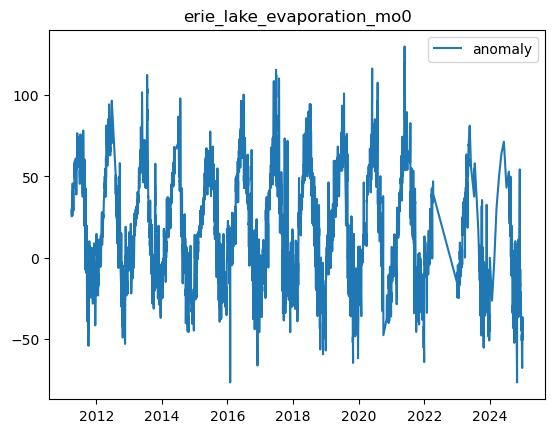

In [51]:
import matplotlib.pyplot as plt

var = "erie_lake_evaporation_mo0"

start_date = "2011-03-01"
end_date = "2026-01-01"

plt.figure()
plt.plot(X_merged.loc[start_date:end_date, var], label="anomaly")
plt.legend()
plt.title(var)
plt.show()

In [52]:
# Initialize model forecaster
model_runner = CNBSForecaster(model_dir, scaler_dir)

# Run predictions for each model
model_predictions = []
for model_name in model_runner.models.keys():
    print(f"Predicting with {model_name}...")
    df_y = model_runner.predict(X_merged, model_name)
    model_predictions.append(df_y)

# Combine all predictions
df_all = pd.concat(model_predictions).reset_index()

Predicting with XGB...
Predicting with GP...
Predicting with NN...
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 275us/step
Predicting with RF...


In [53]:
import re

_MO_RE = re.compile(r"_mo(\d+)$")

def add_climatology_back_leadwide(
    df_anom_leadwide: pd.DataFrame,
    scp_y: "SeasonalCycleProcessor",
    strict: bool = False,
) -> pd.DataFrame:
    """
    Convert lead-wide anomaly targets to lead-wide absolute targets by adding a monthly climatology.

    This is designed for targets that have already been shifted into lead form, where each column
    ends with `_mo{k}` and the DataFrame index represents the *initialization* date.

    Month alignment rule
    --------------------
    For a given init date `t` and lead `k` months, the verifying month is:
        verifying_month = month(t + k months)

    Parameters
    ----------
    df_anom_leadwide : pd.DataFrame
        Anomaly DataFrame indexed by init date (must be a DatetimeIndex).
        Columns must end with `_mo{k}` where k is lead in months, e.g.:
            'superior_target_precipitation_mo0', ..., '..._mo11'

        Values must be in anomaly units (i.e., NOT standardized).

    scp_y : SeasonalCycleProcessor
        A fitted seasonal-cycle processor with attribute `climatology`:
            - index: months 1..12 (int)
            - columns: base (unshifted) variable names, e.g. 'superior_target_precipitation'
            - values: monthly climatological means in absolute units

    strict : bool, default False
        If True, raise an error if any column does not match the `_mo{k}` pattern.

    Returns
    -------
    pd.DataFrame
        Same shape/columns/index as `df_anom_leadwide`, but in absolute units
        (monthly climatology added back to each lead column).
    """
    if not isinstance(df_anom_leadwide.index, pd.DatetimeIndex):
        raise ValueError("df_anom_leadwide must have a DatetimeIndex (init dates).")

    if not hasattr(scp_y, "climatology"):
        raise AttributeError("scp_y must have a `climatology` attribute (fit the processor first).")

    clim = scp_y.climatology

    if not isinstance(clim, pd.DataFrame):
        raise TypeError("scp_y.climatology must be a pandas DataFrame (month x base_var).")

    # Optional sanity check: months should be 1..12
    # (Don't force order; just ensure membership.)
    expected_months = set(range(1, 13))
    clim_months = set(pd.Index(clim.index).astype(int).tolist())
    if not expected_months.issubset(clim_months):
        raise ValueError(
            "scp_y.climatology index must include months 1..12. "
            f"Got: {sorted(clim_months)[:15]}..."
        )

    out = df_anom_leadwide.copy()
    idx = out.index

    for col in out.columns:
        m = _MO_RE.search(col)
        if m is None:
            if strict:
                raise ValueError(f"Column '{col}' does not end with _mo{{k}}.")
            continue

        lead = int(m.group(1))
        base = _MO_RE.sub("", col)  # strip _mo{k}

        if base not in clim.columns:
            raise KeyError(
                f"Base variable '{base}' not found in climatology columns. "
                "This usually means climatology was fit on different variable names."
            )

        verifying_month = (idx + pd.DateOffset(months=lead)).month  # 1..12
        out[col] = out[col].to_numpy() + clim.loc[verifying_month, base].to_numpy()

    return out

In [54]:
scp_y = SeasonalCycleProcessor.load(
    climatology_path="/Users/ljob/Desktop/cnbs-predictor/notebooks/exploratory/artifacts/climatology_targets/climatology.csv",
    metadata_path="/Users/ljob/Desktop/cnbs-predictor/notebooks/exploratory/artifacts/climatology_targets/metadata.json"
)

In [55]:
df_all = df_all.rename(columns={'index': 'cfs_run'})

In [56]:
df_all = df_all.set_index('cfs_run')

In [57]:
scp_y.climatology.columns = [
    c.replace("_target", "") for c in scp_y.climatology.columns
]

In [58]:
df_absolute = add_climatology_back_leadwide(df_all, scp_y)

In [59]:
df_all = df_absolute.reset_index()

# Step 1: Melt into long format
df_melted = df_all.melt(
    id_vars=['cfs_run', 'model'],
    var_name='variable',
    value_name='value'
)

# Step 2: Split into lake, variable, and month_offset
split_cols = df_melted['variable'].str.rsplit('_', n=2, expand=True)
df_melted['component'] = split_cols[0] + '_' + split_cols[1]
df_melted['month_offset'] = split_cols[2].str.replace('mo', '', regex=False).astype(int)

# Step 3: Compute forecast_month
df_melted['forecast_month'] = df_melted.apply(
    lambda row: (pd.to_datetime(row['cfs_run']) + pd.DateOffset(months=row['month_offset'])).strftime('%Y-%m'),
    axis=1
)
df_melted = df_melted.drop(columns=['month_offset'])

# Step 4: Pivot so each variable type is its own column
df_tidy = df_melted.pivot_table(
    index=['cfs_run', 'model', 'forecast_month'],
    columns='component',
    values='value'
).reset_index()
df_tidy.columns.name = None

df_tidy.to_csv('CNBS_forecast_ver.csv', sep='\t', index=False)

In [60]:
df_tidy["date"] = pd.to_datetime(df_tidy["forecast_month"], format="%Y-%m")

In [61]:
#transformer = ForecastTransformer(df_all)

#df_pivot = transformer.pivot()

In [62]:
# Save to a CSV [mm]
#df_pivot.to_csv('CNBS_forecast_ver.csv', sep='\t', index=False)

In [63]:
# Open and load observational data

l2_obs = DataLoader().l2swbm(input_dir + 'l2swbm/')
l2_obs = l2_obs.reset_index()

glcc_obs = DataLoader().glcc(input_dir + 'glcc/', 'mm')
glcc_obs = glcc_obs.reset_index()

In [64]:
# Merge on forecast_month = date
df_merged = pd.merge(
    df_tidy,
    l2_obs,
    on='date',
    how='inner'
)

df_combined = pd.merge(
    df_merged,
    glcc_obs,
    on='date',
    how='inner'
)

df_combined = df_combined.dropna()

In [65]:
from properscoring import crps_ensemble
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

def calculate_ensemble_skill(df, var_list, model, date_col='date'):
    df_model = df[df['model'] == model]

    all_obs = []
    all_pred_means = []
    all_pred_ensembles = []

    for var in var_list:
        pred_col = var
        obs_col = f"{var}_obs"

        #if pred_col not in df_model.columns or obs_col not in df_model.columns:
        #    print(f"Warning: Missing columns for '{var}', skipping.")
        #    continue

        data = df_model[[date_col, pred_col, obs_col]].dropna()

        grouped = data.groupby(date_col)

        for date, group in grouped:
            obs = group[obs_col].iloc[0]  # repeated obs per date
            preds = group[pred_col].values

            all_obs.append(obs)
            all_pred_means.append(np.mean(preds))
            all_pred_ensembles.append(preds)

    all_obs = np.array(all_obs)
    all_pred_means = np.array(all_pred_means)

    rmse = np.sqrt(mean_squared_error(all_obs, all_pred_means))
    r2 = r2_score(all_obs, all_pred_means)
    bias = np.mean(all_pred_means - all_obs)
    var_ratio = np.var(all_pred_means) / np.var(all_obs)
    nse = 1 - np.sum((all_pred_means - all_obs) ** 2) / np.sum((all_obs - np.mean(all_obs)) ** 2)
    r = np.corrcoef(all_obs, all_pred_means)[0, 1]
    alpha = np.std(all_pred_means) / np.std(all_obs)
    beta = np.mean(all_pred_means) / np.mean(all_obs)
    kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)
    crps = np.mean([crps_ensemble(o, p) for o, p in zip(all_obs, all_pred_ensembles)])

    return {
        'Model': model,
        'RMSE': rmse,
        'R2': r2,
        'Bias': bias,
        'VarRatio': var_ratio,
        'NSE': nse,
        'KGE': kge,
        'CRPS': crps
    }

def plot_styled_table(df, title=None):
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.axis('off')  # Hide axes

    # Add title if provided
    if title:
        ax.set_title(title, fontsize=14, fontweight='bold')#, pad=20)

    table_data = [df.columns.to_list()] + df.round(3).values.tolist()

    table = ax.table(
        cellText=table_data,
        loc='upper center',
        cellLoc='center',
        edges='closed'
    )

    # Header styling
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor('#d3d3d3')
            cell.get_text().set_fontweight('bold')
        cell.get_text().set_fontsize(12)

    # Adjust cell dimensions
    for (row, col), cell in table.get_celld().items():
        cell.set_height(0.17)
        if col == 0:
            cell.set_width(0.2)
        else:
            cell.set_width(0.15)

    table.auto_set_font_size(False)
    plt.show()

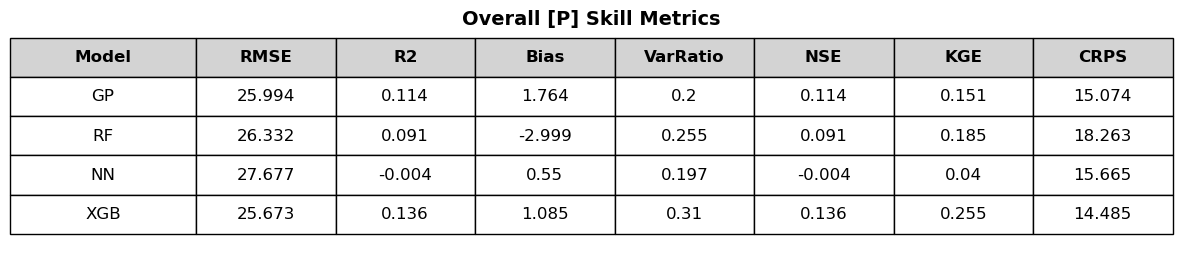

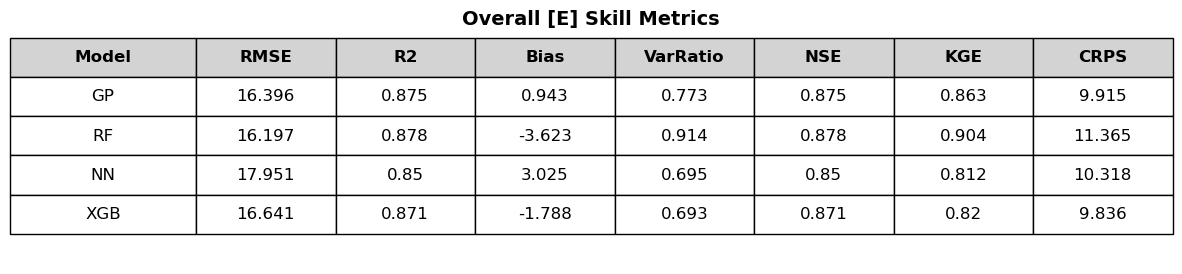

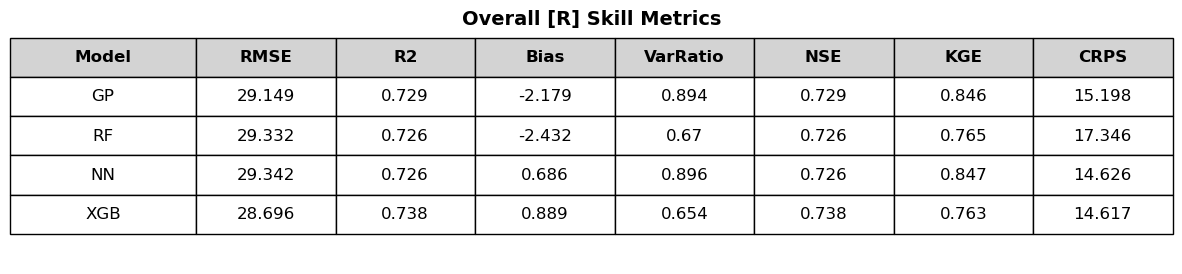

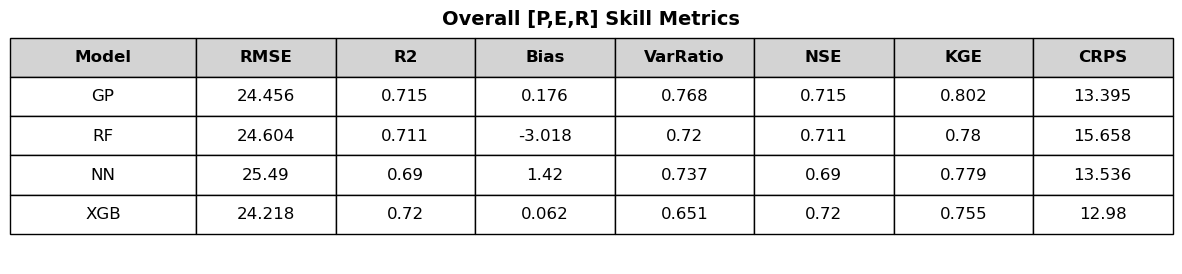

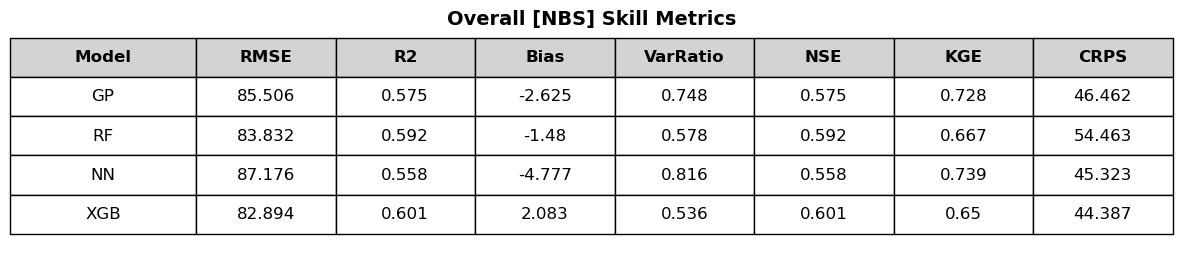

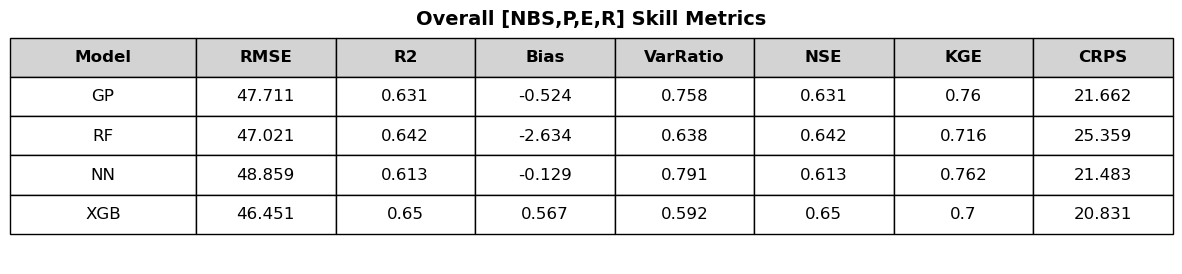

In [66]:
# lakes and models stay constant
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
models = ['GP', 'RF', 'NN', 'XGB']

# component configurations and plot titles
component_configs = [
    (['precipitation'], "Overall [P] Skill Metrics"),
    (['evaporation'], "Overall [E] Skill Metrics"),
    (['runoff'], "Overall [R] Skill Metrics"),
    (['precipitation', 'evaporation', 'runoff'], "Overall [P,E,R] Skill Metrics"),
    (['nbs'], "Overall [NBS] Skill Metrics"),
    (['nbs', 'precipitation', 'evaporation', 'runoff'], "Overall [NBS,P,E,R] Skill Metrics"),
]

# loop over each configuration
for components, title in component_configs:

    # build variable list
    var_list = [f"{lake}_{comp}" for lake in lakes for comp in components]

    # calculate skill for each model
    results = []
    for m in models:
        skill = calculate_ensemble_skill(
            df_combined,
            var_list,
            m,
            date_col='date'
        )
        results.append(skill)

    # convert to DataFrame
    results_df = pd.DataFrame(results)

    # plot
    plot_styled_table(results_df, title=title)


In [67]:
df_tidy['cfs_run'] = pd.to_datetime(df_tidy['cfs_run'])
df_tidy['forecast_month'] = pd.to_datetime(df_tidy['forecast_month'])

# For each forecast run, keep only the first 6 months
df_first6 = (
    df_combined.sort_values(['cfs_run', 'forecast_month'])
      .groupby(['cfs_run', 'model'])
      .head(6)  # keep first 6 rows per run/model
      .reset_index(drop=True)
)

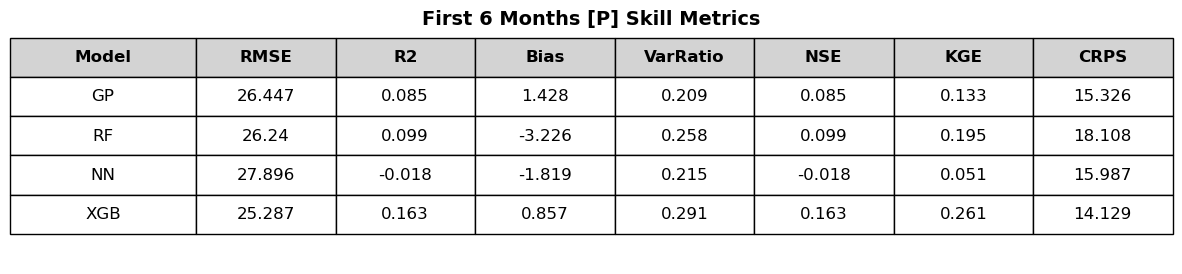

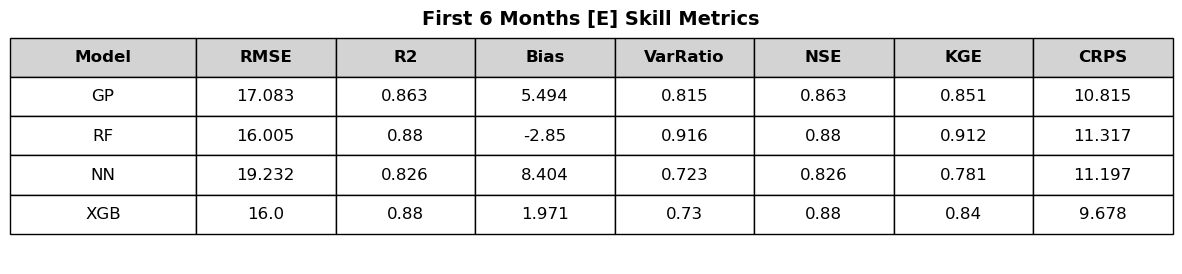

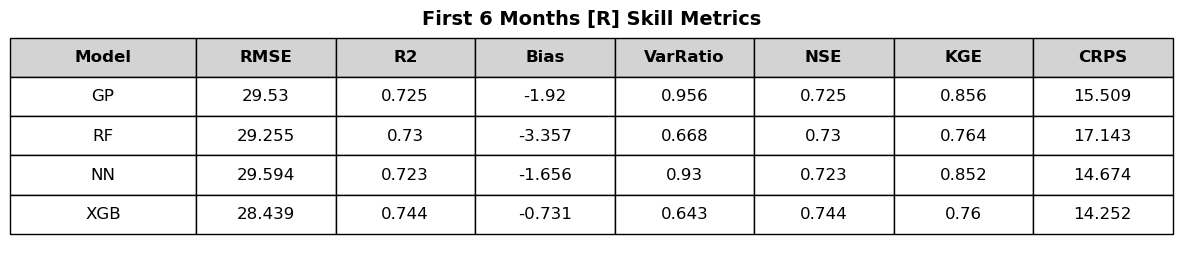

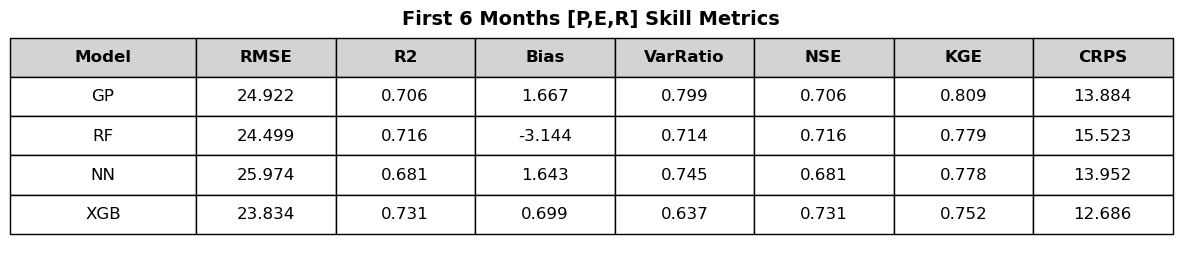

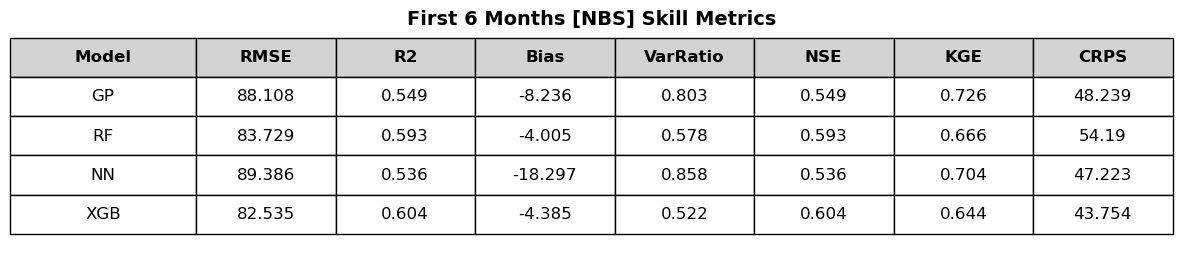

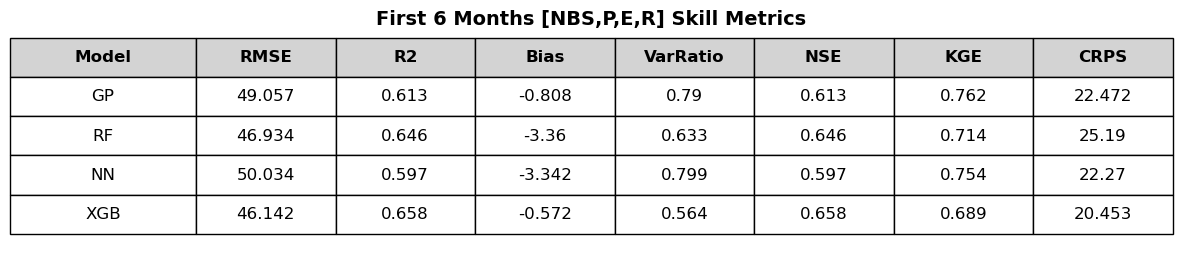

In [68]:
# lakes and models stay constant
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
models = ['GP', 'RF', 'NN', 'XGB']

# component configurations and plot titles
component_configs = [
    (['precipitation'], "First 6 Months [P] Skill Metrics"),
    (['evaporation'], "First 6 Months [E] Skill Metrics"),
    (['runoff'], "First 6 Months [R] Skill Metrics"),
    (['precipitation', 'evaporation', 'runoff'], "First 6 Months [P,E,R] Skill Metrics"),
    (['nbs'], "First 6 Months [NBS] Skill Metrics"),
    (['nbs', 'precipitation', 'evaporation', 'runoff'], "First 6 Months [NBS,P,E,R] Skill Metrics"),
]

# loop over each configuration
for components, title in component_configs:

    # build variable list
    var_list = [f"{lake}_{comp}" for lake in lakes for comp in components]

    # calculate skill for each model
    results = []
    for m in models:
        skill = calculate_ensemble_skill(
            df_first6,
            var_list,
            m,
            date_col='date'
        )
        results.append(skill)

    # convert to DataFrame
    results_df = pd.DataFrame(results)

    # plot
    plot_styled_table(results_df, title=title)

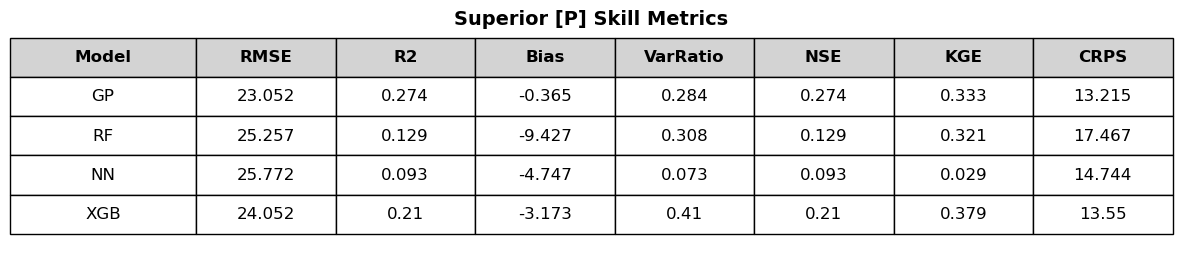

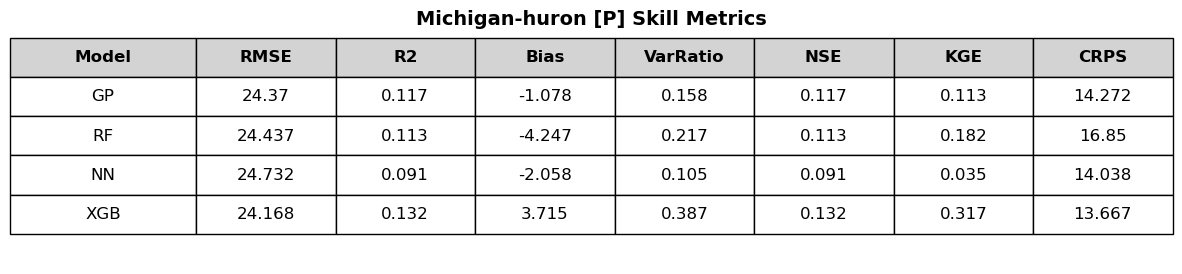

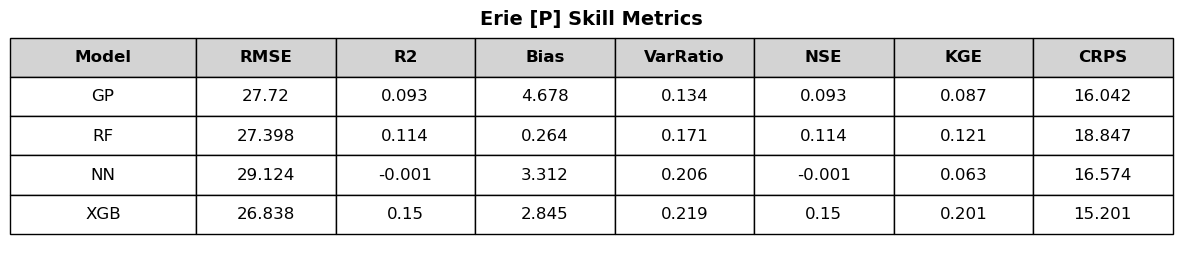

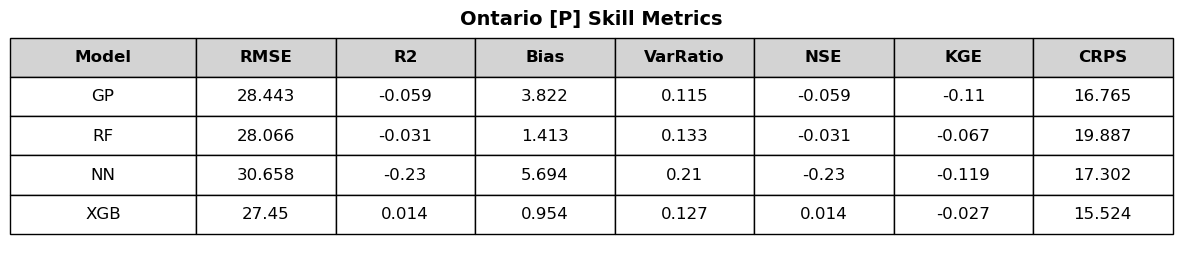

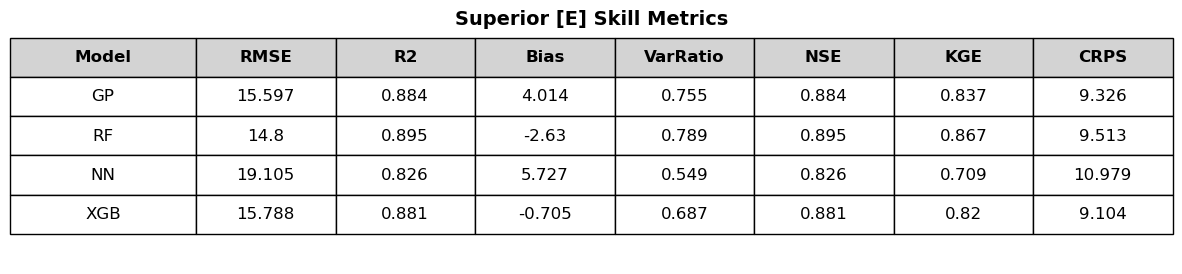

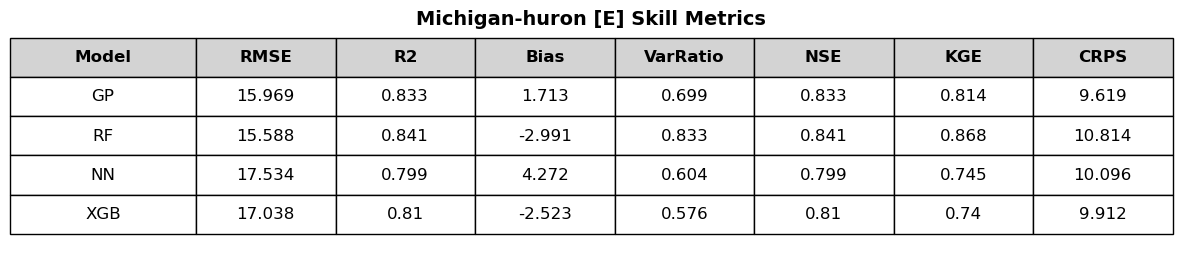

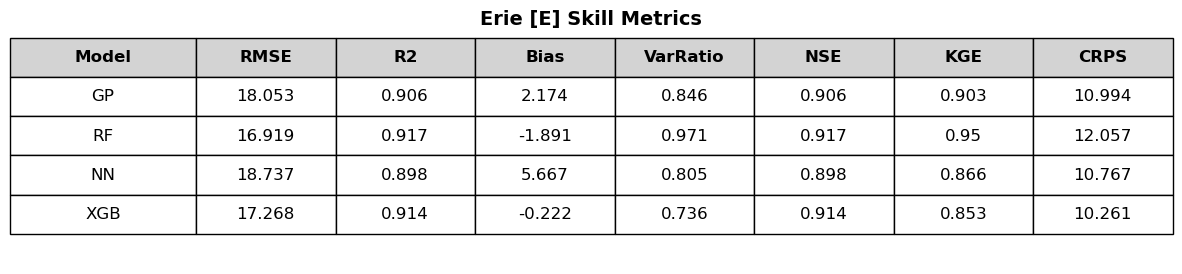

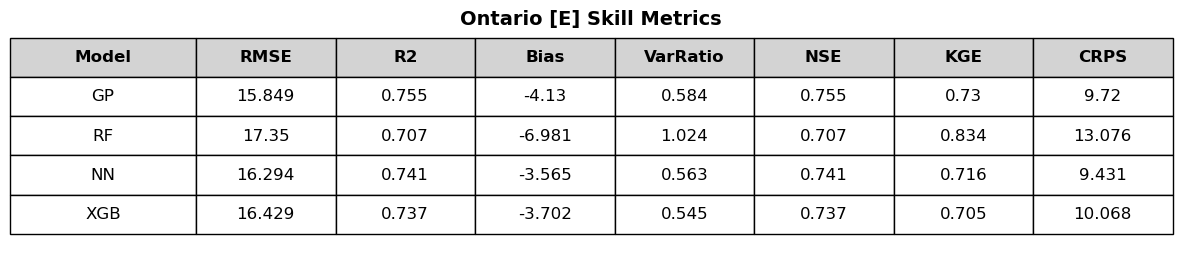

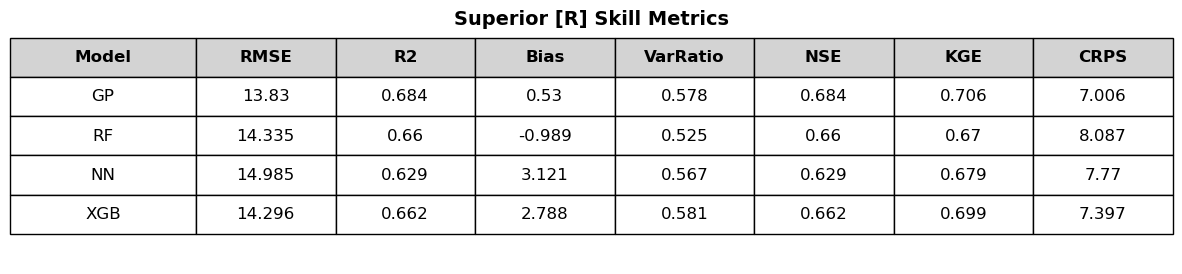

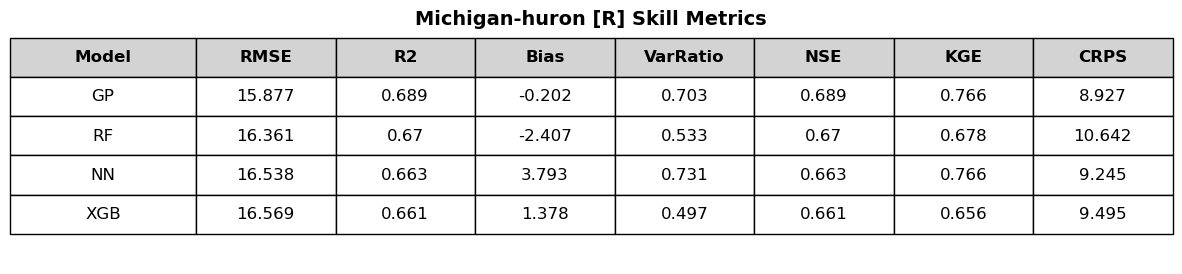

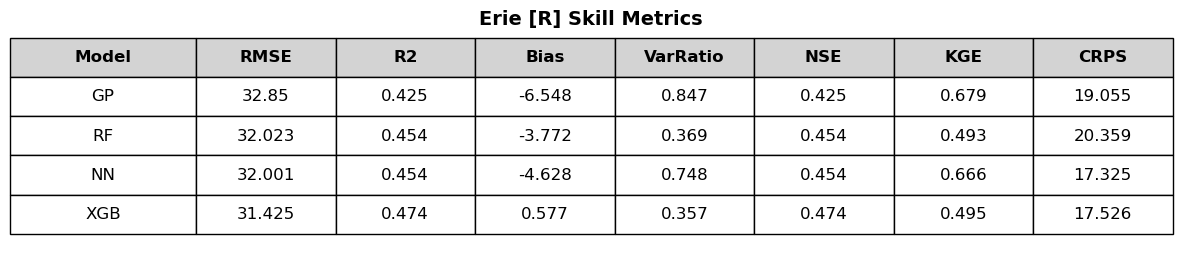

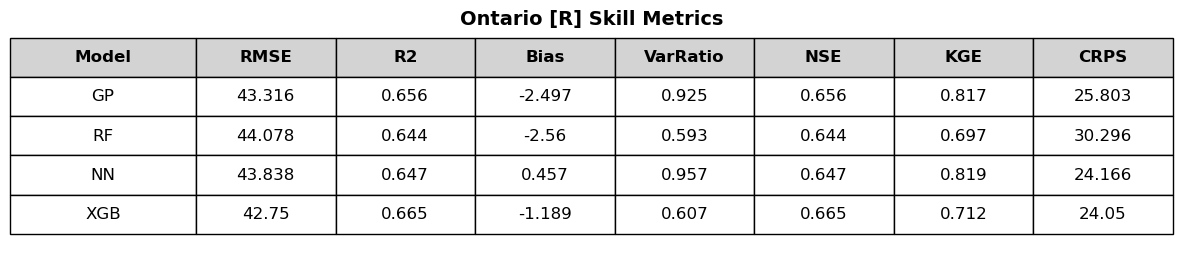

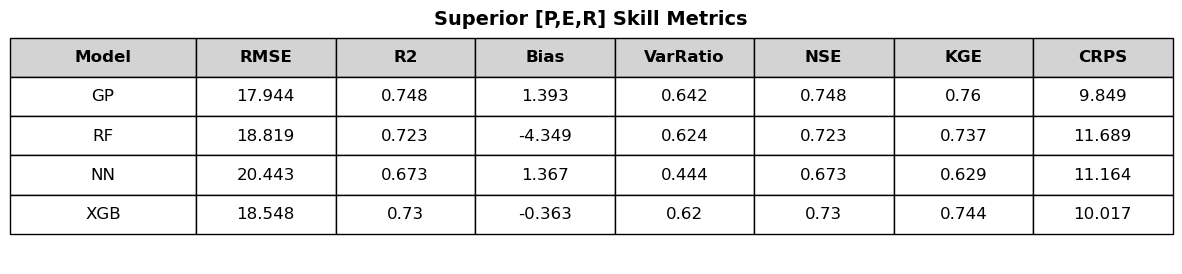

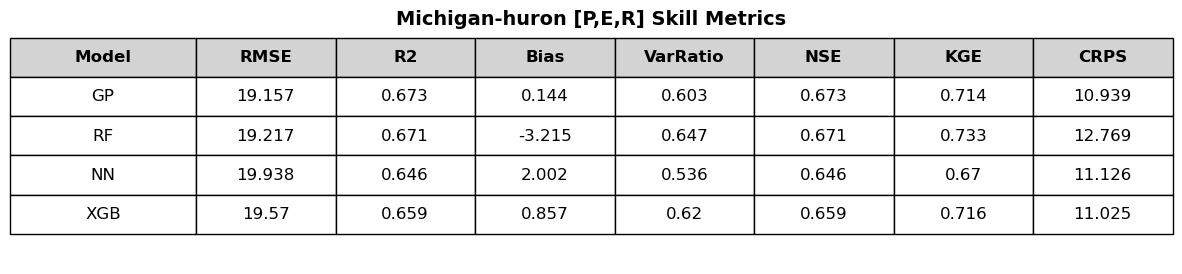

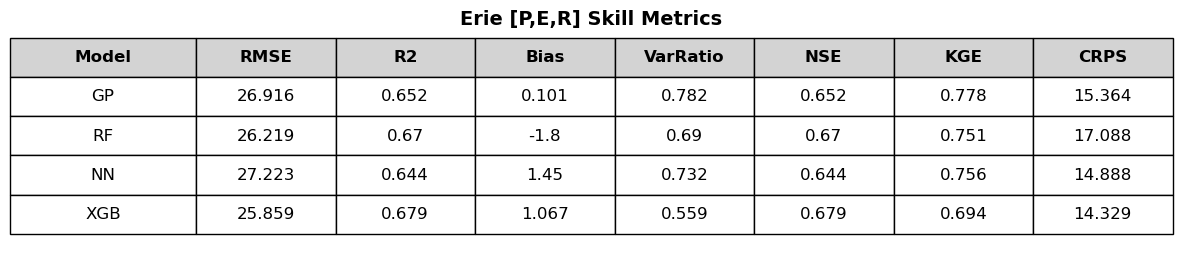

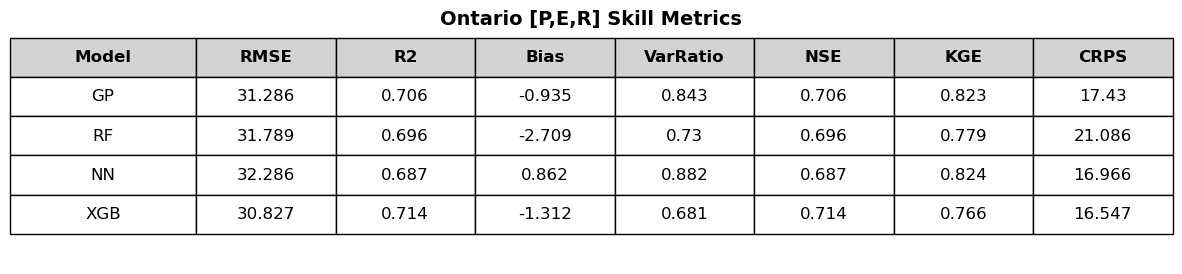

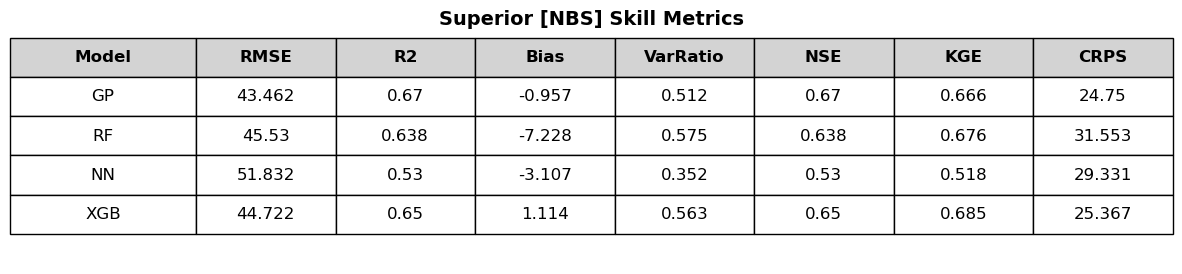

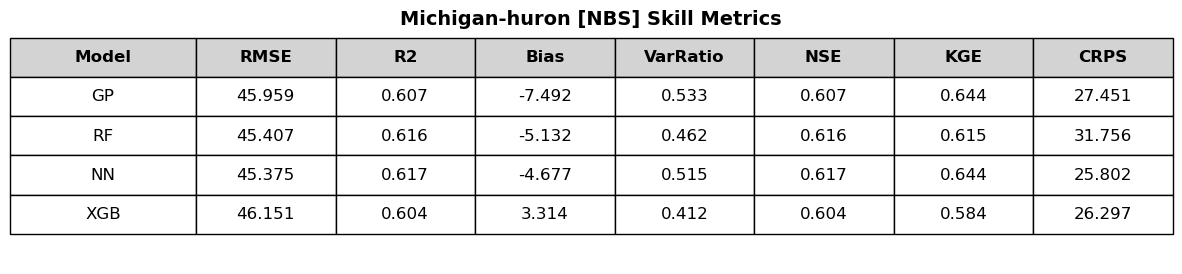

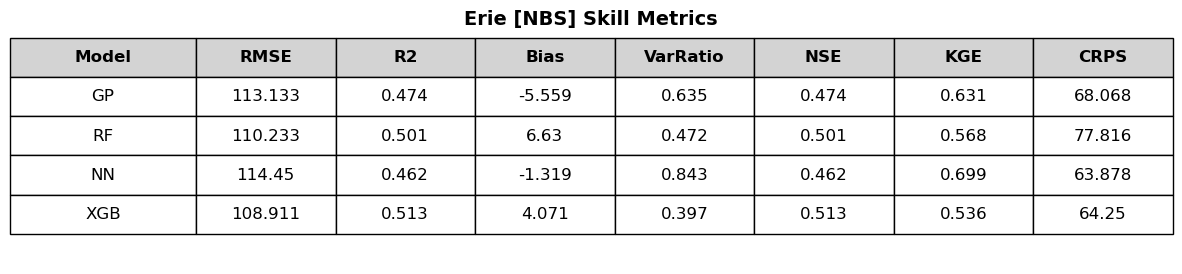

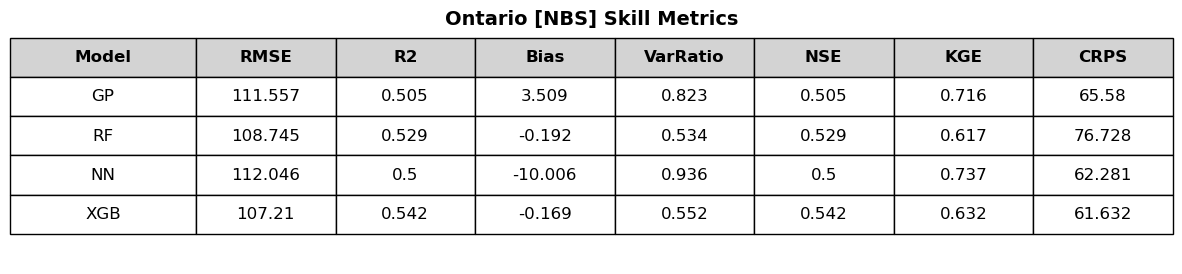

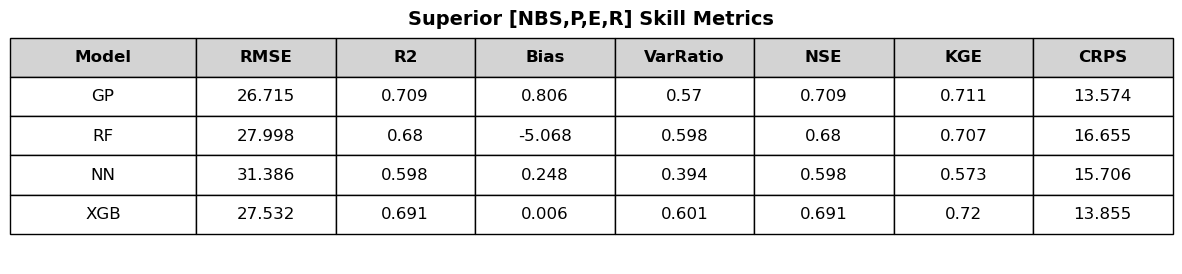

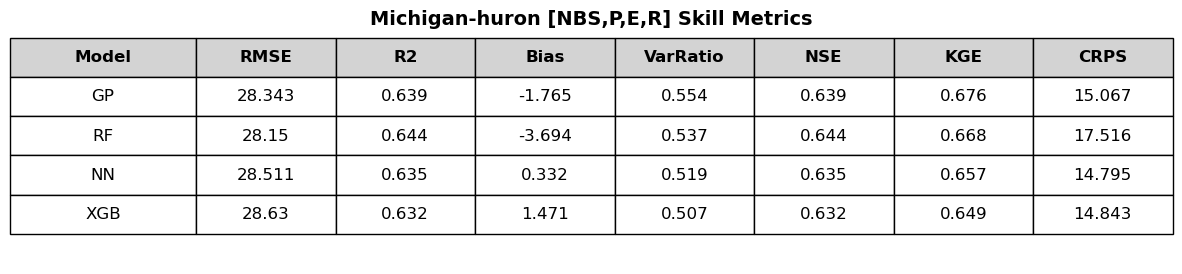

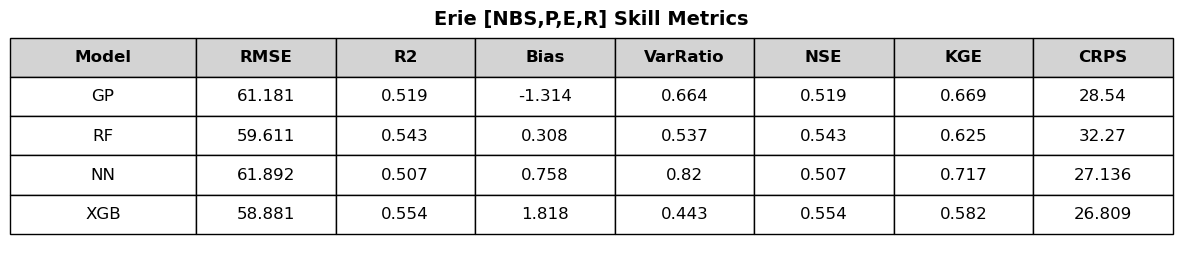

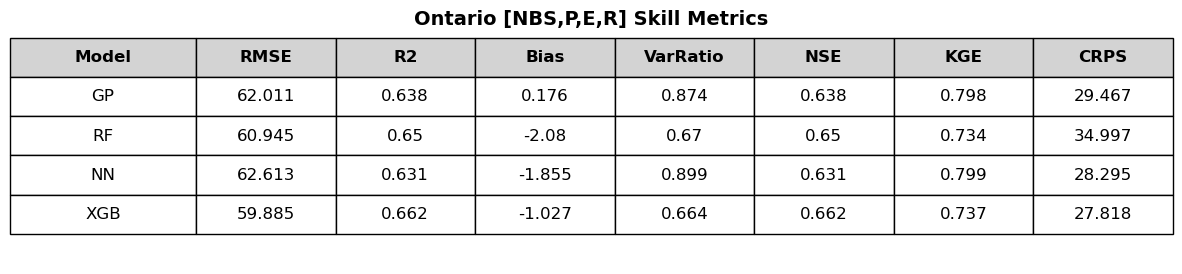

In [69]:
# lakes and models stay constant
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
models = ['GP', 'RF', 'NN', 'XGB']

# component configurations and plot titles
component_configs = [
    (['precipitation'], " [P] Skill Metrics"),
    (['evaporation'], " [E] Skill Metrics"),
    (['runoff'], " [R] Skill Metrics"),
    (['precipitation', 'evaporation', 'runoff'], " [P,E,R] Skill Metrics"),
    (['nbs'], " [NBS] Skill Metrics"),
    (['nbs', 'precipitation', 'evaporation', 'runoff'], " [NBS,P,E,R] Skill Metrics"),
]

#all_results = []

# loop over each configuration
for components, title in component_configs:

    # loop over each lake
    for lake in lakes:

        # build variable list for THIS lake only
        var_list = [f"{lake}_{comp}" for comp in components]
        all_results = []
        # calculate skill for each model
        for m in models:

            skill = calculate_ensemble_skill(
                df_combined,
                var_list,
                m,
                date_col='date'
            )

            all_results.append(skill)

        table_df = pd.DataFrame(all_results)

        plot_styled_table(
            table_df,
            title=f"{lake.capitalize()}{title}"
        )

In [70]:
print(data)

            cfs_run  year  month      lake surface_type        component  \
0        2011040100  2011      4      erie         lake  air_temperature   
1        2011040100  2011      4      erie         lake      evaporation   
2        2011040100  2011      4      erie         lake    precipitation   
3        2011040100  2011      4      erie         land  air_temperature   
4        2011040100  2011      4      erie         land      evaporation   
...             ...   ...    ...       ...          ...              ...   
4394720  2026030118  2026     12  superior         lake      evaporation   
4394721  2026030118  2026     12  superior         lake    precipitation   
4394722  2026030118  2026     12  superior         land  air_temperature   
4394723  2026030118  2026     12  superior         land      evaporation   
4394724  2026030118  2026     12  superior         land    precipitation   

         value [mm]                    column_name forecast_date  
0        278.204989 

In [71]:
df = data.copy()

# 2. Filter only surface_type == lake
df = df[df["surface_type"] == "lake"]

# 3. Create "variable" column
df["variable"] = df["lake"] + "_" + df["component"]

# 4. Pivot to wide format
pivot_df = df.pivot_table(
    index=["cfs_run", "forecast_date"],  # keep these as identifiers
    columns="variable",
    values="value [mm]",
    aggfunc="mean"  # in case of duplicates
).reset_index()

# Optional: flatten column names after pivot
pivot_df.columns.name = None  # remove pivot column grouping name

df_cfs_mean =(pivot_df.groupby(["forecast_date"]).mean(numeric_only=True))
df_cfs = df_cfs_mean.reset_index()

In [72]:
df_mean = df_combined.groupby(['forecast_month','model']).mean()
df_mean = df_mean.reset_index()

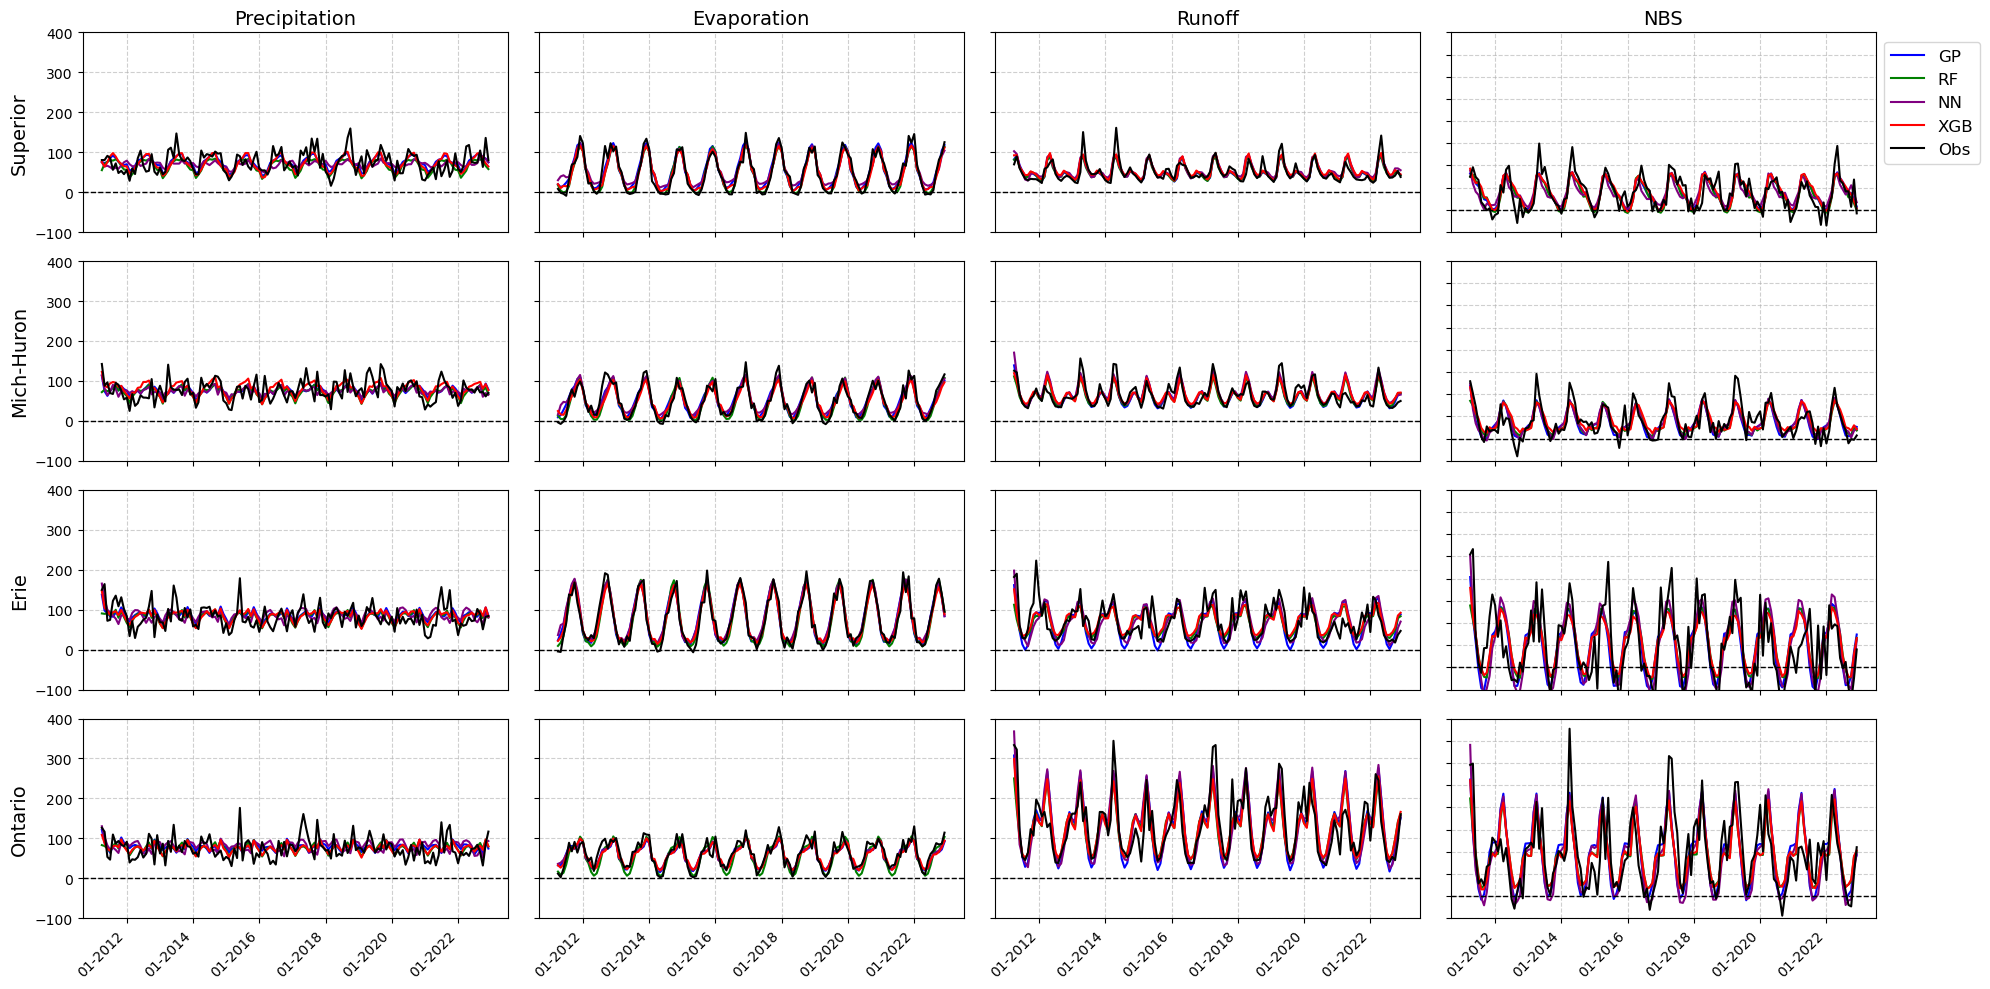

In [73]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# Define model colors
model_colors = {'GP': 'blue', 'RF': 'green', 'XGB': 'red', 'NN': 'purple'}

# Define lake names and components
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
components = ['precipitation', 'evaporation', 'runoff', 'nbs']
titles = ['Precipitation', 'Evaporation', 'Runoff', 'NBS']
ylabels = ['Superior', 'Mich-Huron', 'Erie', 'Ontario']

# Create subplot grid
fig, axs = plt.subplots(4, 4, figsize=(20, 10))
axs = axs.reshape(4, 4)

# Loop through all combinations of lake and component
for row, lake in enumerate(lakes):
    for col, comp in enumerate(components):
        ax = axs[row, col]
        column = f'{lake}_{comp}'
        obs_column = f'{column}_obs'

        for model_name in models_info:
            model_df = df_mean[df_mean['model'] == model_name].copy()
            
            # Plot model prediction
            ax.plot(model_df['date'], model_df[column],
                    color=model_colors[model_name], label=model_name)

        # Plot observations
        ax.plot(model_df['date'], model_df[obs_column],
                color='black', linewidth=1.5, label='Obs')

        # Only plot CFS for precipitation + evaporation
        #if comp in ['precipitation', 'evaporation']:
        #    ax.plot(df_cfs['date'], df_cfs[column],
        #            color='orange', linewidth=1.5, label='CFS')
        
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.set_yticks(np.arange(-1000, 1000, 100))

        # Set titles and labels
        if row == 0:
            ax.set_title(titles[col], fontsize=14)
        if row == 3:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
            ax.tick_params(axis='x', rotation=45)
            for label in ax.get_xticklabels():
                label.set_horizontalalignment('right')
        else:
            ax.set_xticklabels([])

        if col == 0:
            ax.set_ylabel(ylabels[row], fontsize=14)
        else:
            ax.set_yticklabels([])
        if col == 3:
            ax.set_ylim(-100, 800)
        else:
            ax.set_ylim(-100, 400)

# Add legend once
axs[0, 3].legend(loc='lower left', bbox_to_anchor=(1, 0.3), fontsize=12)

start_date = pd.to_datetime('2014-01-01')
end_date = pd.to_datetime('2015-01-01')

#for ax_row in axs:
#    for ax in ax_row:
#        ax.set_xlim(start_date, end_date)

# Save and show plot
plt.tight_layout()
plt.savefig('CNBS_forecasts.png', dpi=300)
plt.show()


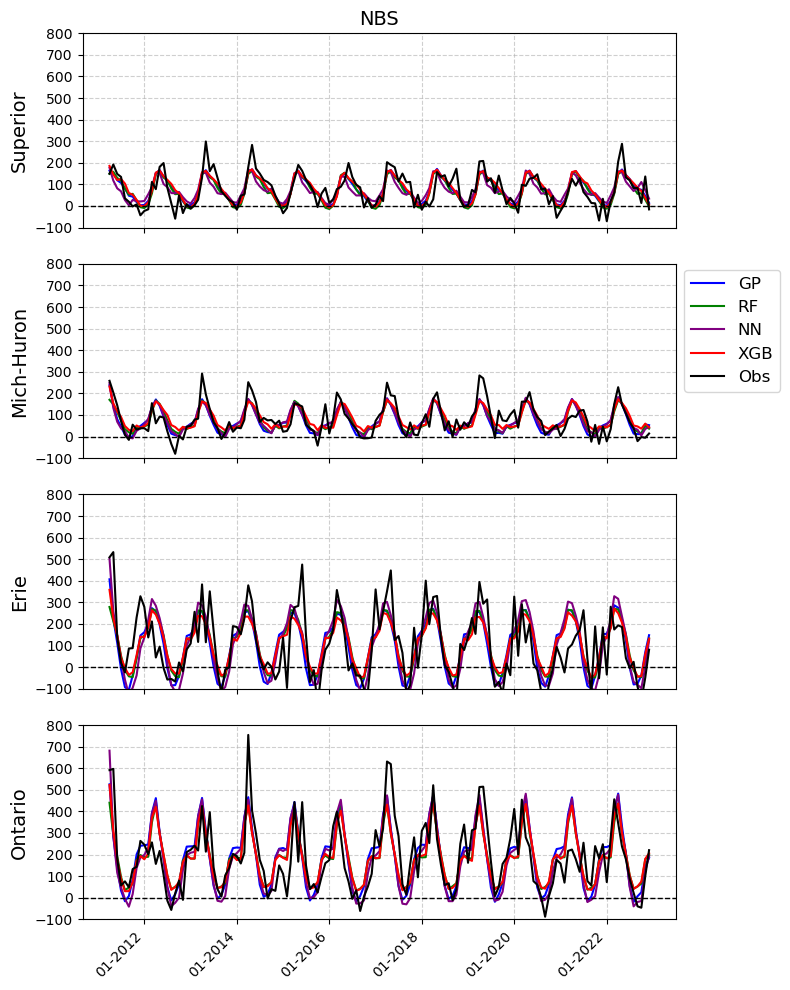

In [74]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# Define model colors
model_colors = {'GP': 'blue', 'RF': 'green', 'XGB': 'red', 'NN': 'purple'}

# Define lake names and components
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
components = ['nbs']
titles = ['NBS']
ylabels = ['Superior', 'Mich-Huron', 'Erie', 'Ontario']

# Create subplot grid
fig, axs = plt.subplots(4, 1, figsize=(8, 10))
axs = axs.reshape(4, 1)

# Loop through all combinations of lake and component
for row, lake in enumerate(lakes):
    for col, comp in enumerate(components):
        ax = axs[row, col]
        column = f'{lake}_{comp}'
        obs_column = f'{column}_obs'

        for model_name in models_info:
            model_df = df_mean[df_mean['model'] == model_name].copy()
            
            # Plot model prediction
            ax.plot(model_df['date'], model_df[column],
                    color=model_colors[model_name], label=model_name)

        # Plot observations
        ax.plot(model_df['date'], model_df[obs_column],
                color='black', linewidth=1.5, label='Obs')

        # Only plot CFS for precipitation + evaporation
        #if comp in ['precipitation', 'evaporation']:
        #    ax.plot(df_cfs['date'], df_cfs[column],
        #            color='orange', linewidth=1.5, label='CFS')
        
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.set_yticks(np.arange(-1000, 1000, 100))

        # Set titles and labels
        if row == 0:
            ax.set_title(titles[col], fontsize=14)
        if row == 3:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
            ax.tick_params(axis='x', rotation=45)
            for label in ax.get_xticklabels():
                label.set_horizontalalignment('right')
        else:
            ax.set_xticklabels([])

        if col == 0:
            ax.set_ylabel(ylabels[row], fontsize=14)
        else:
            ax.set_yticklabels([])
        if col == 3:
            ax.set_ylim(-100, 800)
        else:
            ax.set_ylim(-100, 800)

# Add legend once
axs[1, 0].legend(loc='lower left', bbox_to_anchor=(1, 0.3), fontsize=12)

start_date = pd.to_datetime('2014-01-01')
end_date = pd.to_datetime('2015-01-01')

#for ax_row in axs:
#    for ax in ax_row:
#        ax.set_xlim(start_date, end_date)

# Save and show plot
plt.tight_layout()
plt.savefig('NBS_forecasts.png', dpi=300)
plt.show()

Calculate skill metrics based on month and season

In [75]:
import pandas as pd

# ensure datetime
df = df_combined.copy()
df['forecast_month_dt'] = pd.to_datetime(df['forecast_month'])

# numeric month (1–12)
df['month'] = df['forecast_month_dt'].dt.month

# month name (Jan, Feb, etc.) – optional but nice for plots
df['month_name'] = df['forecast_month_dt'].dt.strftime('%b')


In [76]:
def month_to_season(month):
    if month in [12, 1, 2]:
        return 'DJF'
    elif month in [3, 4, 5]:
        return 'MAM'
    elif month in [6, 7, 8]:
        return 'JJA'
    else:
        return 'SON'

df['season'] = df['month'].apply(month_to_season)


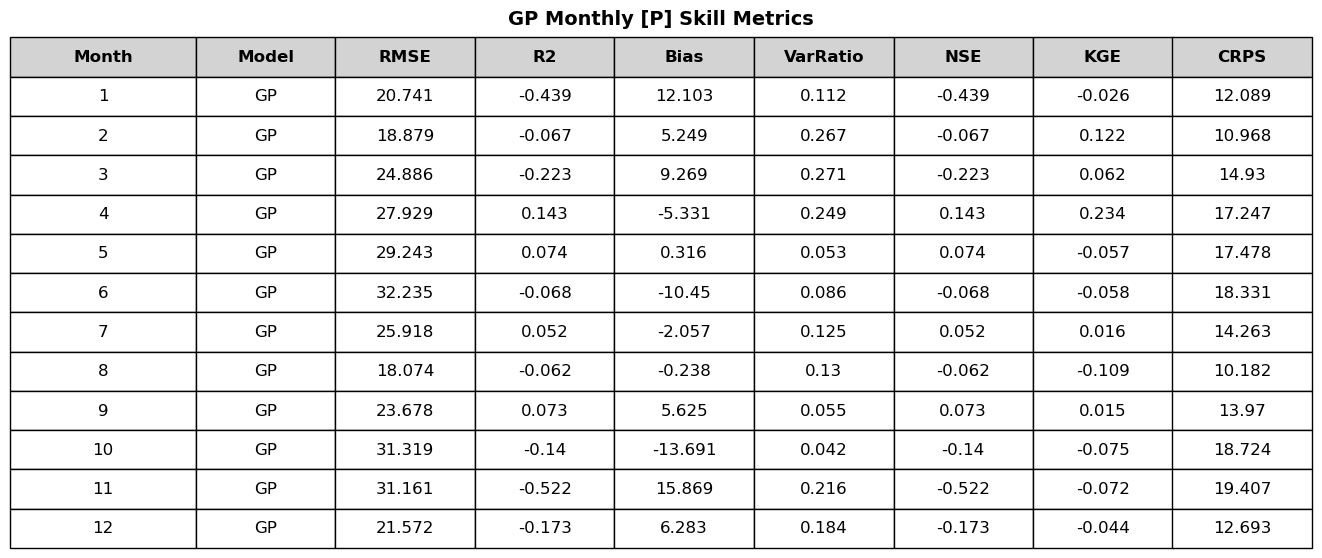

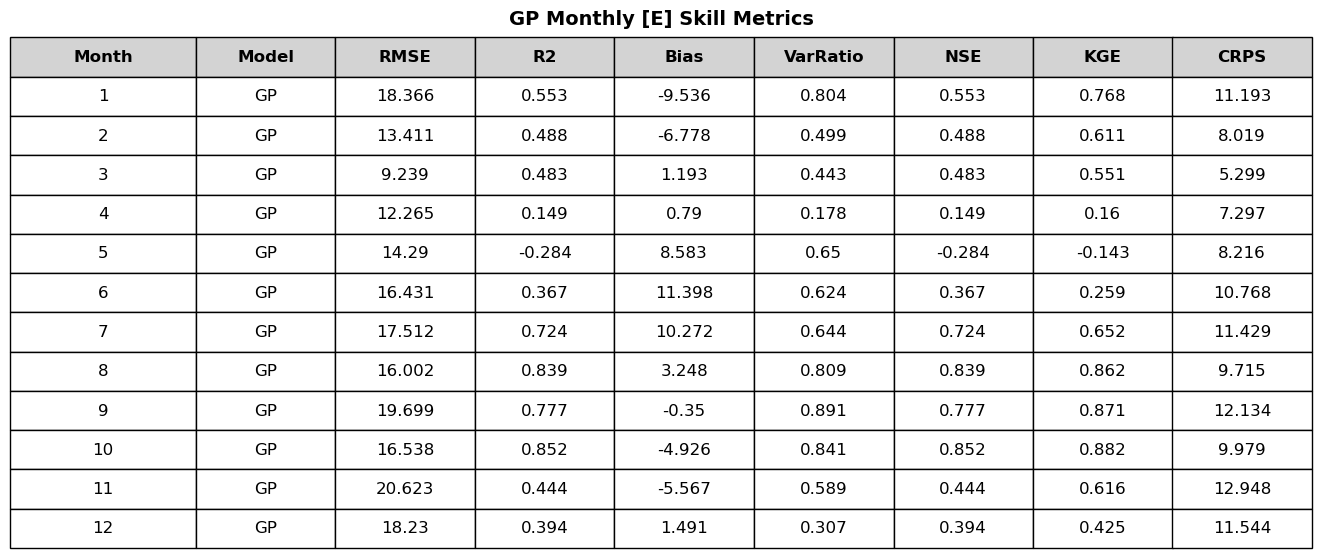

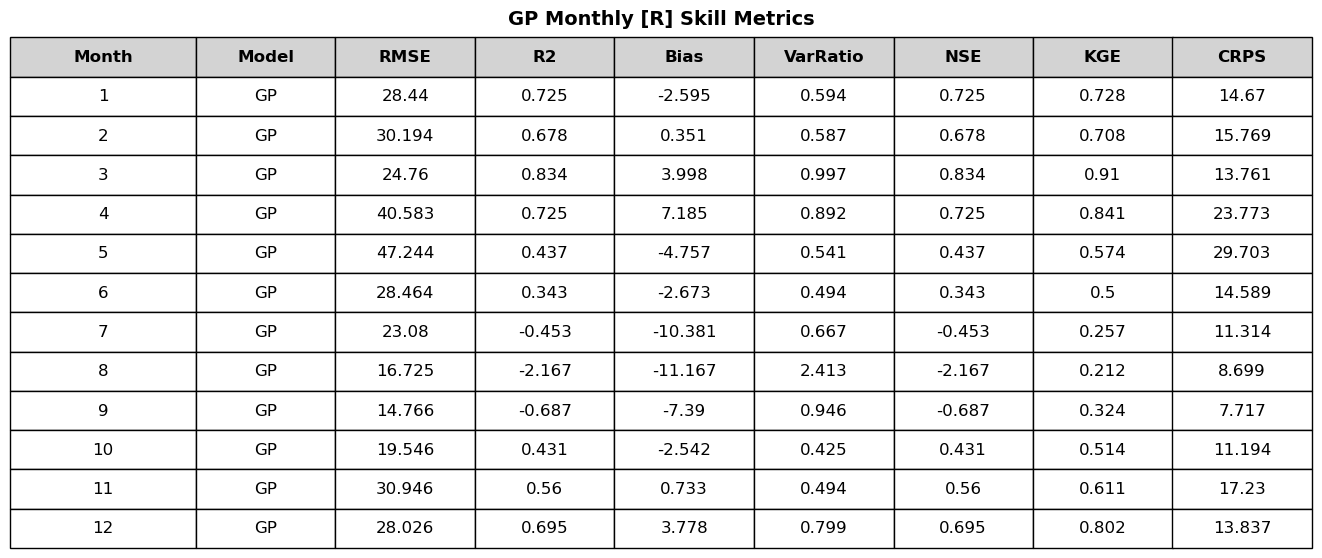

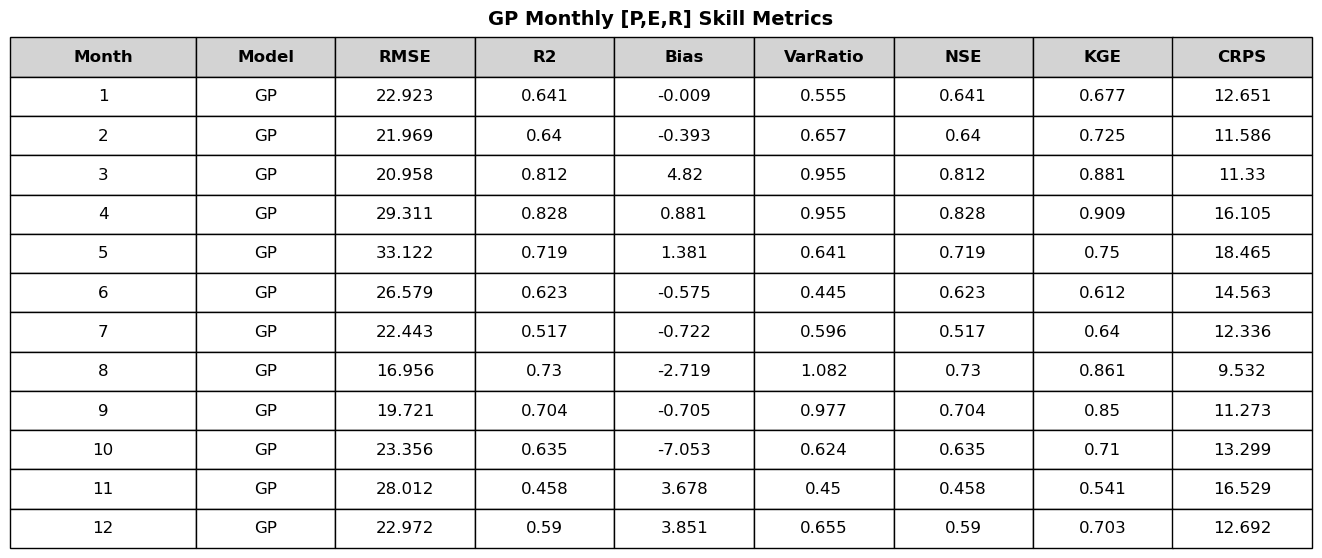

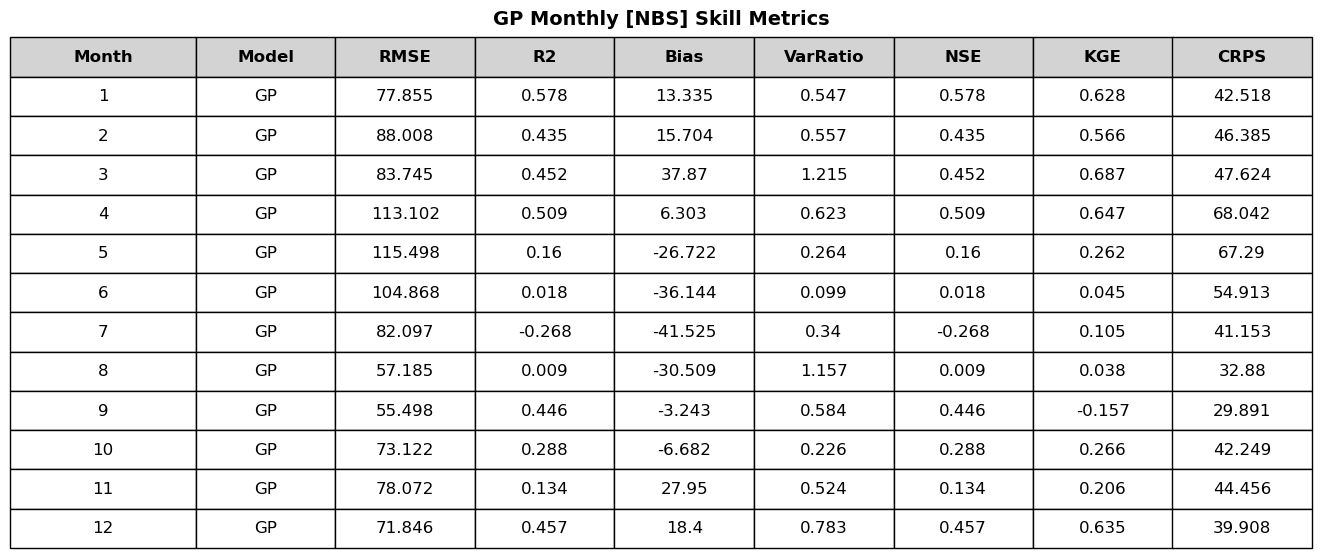

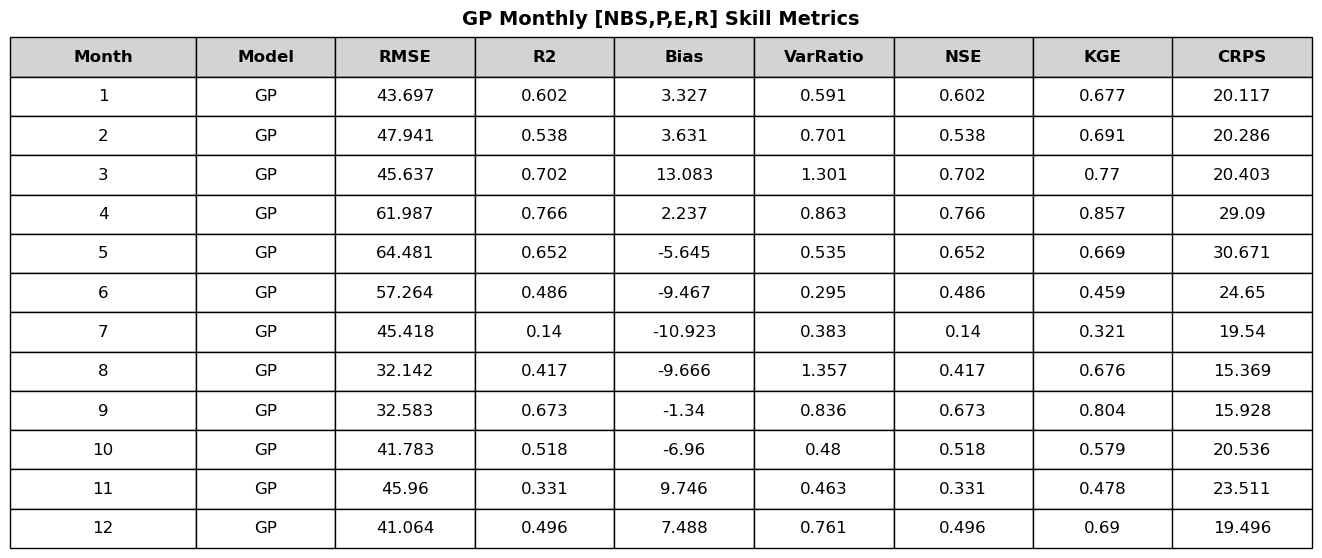

In [77]:
# lakes and models stay constant
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
models = ['GP']

# component configurations and plot titles
component_configs = [
    (['precipitation'], "GP Monthly [P] Skill Metrics"),
    (['evaporation'], "GP Monthly [E] Skill Metrics"),
    (['runoff'], "GP Monthly [R] Skill Metrics"),
    (['precipitation', 'evaporation', 'runoff'], "GP Monthly [P,E,R] Skill Metrics"),
    (['nbs'], "GP Monthly [NBS] Skill Metrics"),
    (['nbs', 'precipitation', 'evaporation', 'runoff'], "GP Monthly [NBS,P,E,R] Skill Metrics"),
]

for components, title in component_configs:

    # build variable list
    var_list = [f"{lake}_{comp}" for lake in lakes for comp in components]

    monthly_results = []

    for month in range(1, 13):
        df_month = df[df['month'] == month]

        if df_month.empty:
            continue

        for model in models:
            skill = calculate_ensemble_skill(
                df_month,
                var_list,
                model,
                date_col='forecast_month_dt'
            )

            skill['Month'] = month
            monthly_results.append(skill)

    # build DataFrame
    monthly_skill_df = pd.DataFrame(monthly_results)

    if monthly_skill_df.empty:
        continue

    # ------------------------------
    # Clean up columns before plot
    # ------------------------------
    monthly_skill_df = monthly_skill_df.drop(
        columns=[c for c in ['month_name', 'model'] if c in monthly_skill_df.columns]
    )

    # ensure Month is first
    cols = ['Month'] + [c for c in monthly_skill_df.columns if c != 'Month']
    monthly_skill_df = monthly_skill_df[cols]

    # ------------------------------
    # Plot
    # ------------------------------
    plot_styled_table(
        monthly_skill_df,
        title=title
    )

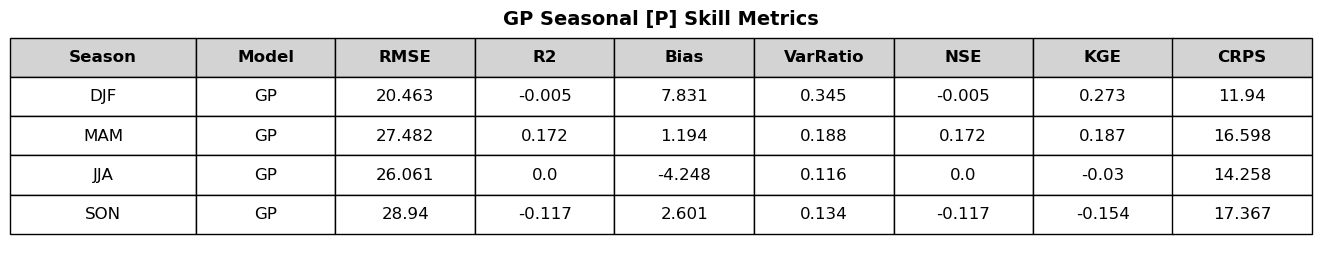

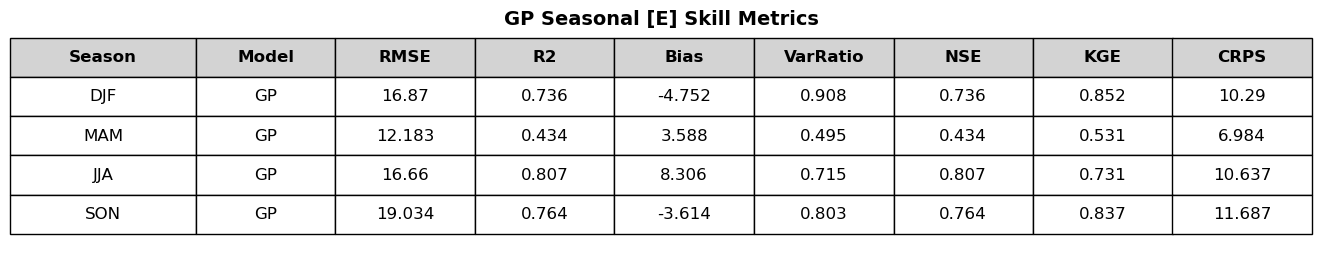

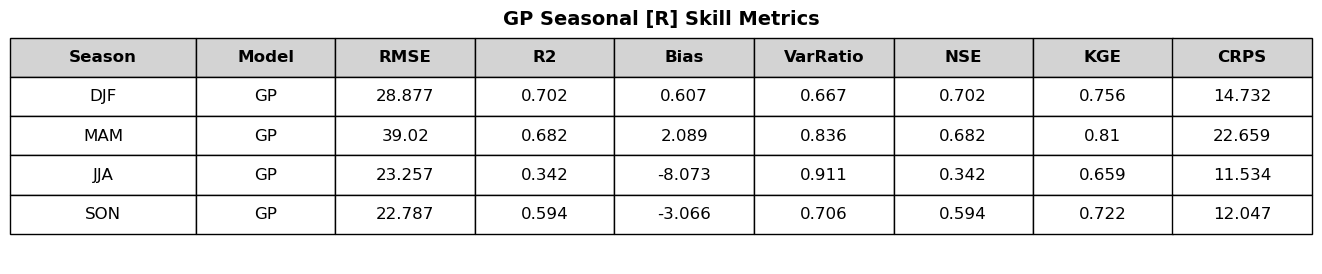

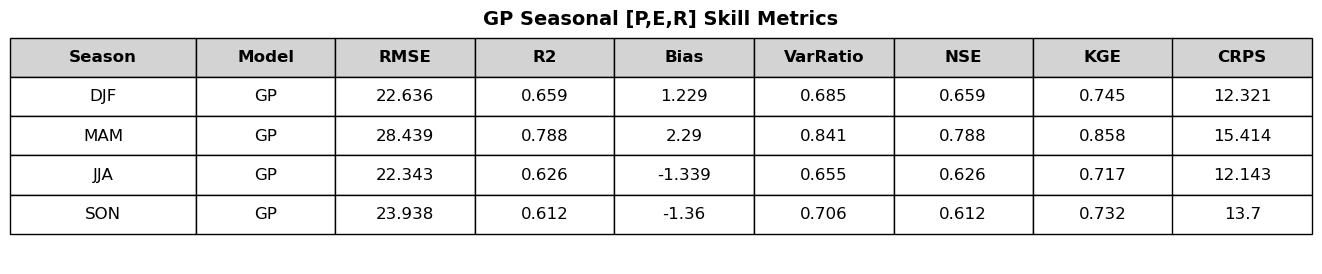

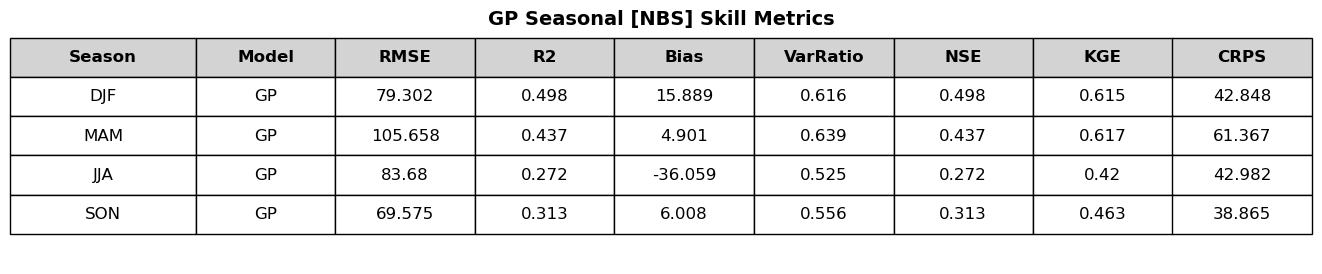

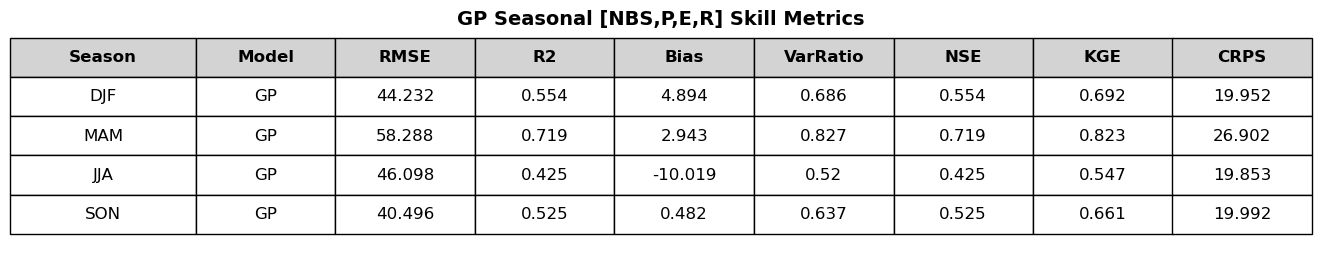

In [78]:
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
models = ['GP']

component_configs = [
    (['precipitation'], "GP Seasonal [P] Skill Metrics"),
    (['evaporation'], "GP Seasonal [E] Skill Metrics"),
    (['runoff'], "GP Seasonal [R] Skill Metrics"),
    (['precipitation', 'evaporation', 'runoff'], "GP Seasonal [P,E,R] Skill Metrics"),
    (['nbs'], "GP Seasonal [NBS] Skill Metrics"),
    (['nbs', 'precipitation', 'evaporation', 'runoff'], "GP Seasonal [NBS,P,E,R] Skill Metrics"),
]

for components, title in component_configs:

    # build variable list
    var_list = [f"{lake}_{comp}" for lake in lakes for comp in components]

    seasonal_results = []

    for season in ['DJF', 'MAM', 'JJA', 'SON']:
        df_season = df[df['season'] == season]

        if df_season.empty:
            continue

        for model in models:
            skill = calculate_ensemble_skill(
                df_season,
                var_list,
                model,
                date_col='forecast_month_dt'
            )

            skill['Season'] = season
            seasonal_results.append(skill)

    # build DataFrame
    seasonal_skill_df = pd.DataFrame(seasonal_results)

    if seasonal_skill_df.empty:
        continue

    # ------------------------------
    # Clean up columns before plot
    # ------------------------------
    seasonal_skill_df = seasonal_skill_df.drop(
        columns=[c for c in ['season', 'model'] if c in seasonal_skill_df.columns]
    )

    # ensure Season is first
    cols = ['Season'] + [c for c in seasonal_skill_df.columns if c != 'Season']
    seasonal_skill_df = seasonal_skill_df[cols]

    # ------------------------------
    # Plot
    # ------------------------------
    plot_styled_table(
        seasonal_skill_df,
        title=title
    )

